## Install Required libraries

In [277]:
# these are mostly to apply BERT model but since i am planning to work on this project ahead i have installed it 

In [5]:
!pip install transformers

   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   -------------------- ------------------- 5.2/10.1 MB 35.6 MB/s eta 0:00:01
   ---------------------------------------  10.0/10.1 MB 44.5 MB/s eta 0:00:01
   ---------------------------------------- 10.1/10.1 MB 25.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 45.3 MB/s eta 0:00:00


In [7]:
!pip install wget

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9680 sha256=32fcddcdc08b194d15dcf0292327bcdd3545df5e713ff5759d2dfbb95fd97fff
  Stored in directory: c:\users\magnus\appdata\local\pip\cache\wheels\01\46\3b\e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [11]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
     ---------------------------------------- 0.0/205.4 MB ? eta -:--:--
     ---------------------------------------- 0.5/205.4 MB 3.4 MB/s eta 0:01:01
      -------------------------------------- 4.7/205.4 MB 15.0 MB/s eta 0:00:14
     -- ----------------------------------- 14.4/205.4 MB 27.4 MB/s eta 0:00:07
     ---- --------------------------------- 26.0/205.4 MB 35.0 MB/s eta 0:00:06
     ------- ------------------------------ 38.8/205.4 MB 40.4 MB/s eta 0:00:05
     --------- ---------------------------- 50.9/205.4 MB 43.2 MB/s eta 0:00:04
     ------------ ------------------------- 65.0/205.4 MB 47.1 MB/s eta 0:00:03
     -------------- ----------------------- 76.8/205.4 MB 48.0 MB/s eta 0:00:03
     ---------------- --------------------- 88.9/205.4 MB 49.3 MB/s eta 0:00:03
     ------------------ ------------------ 100.7/205.4 MB 49.8 MB/s eta 0:00:03
     -------------------- ---------------- 111.9/205.4 MB 50.0 MB/s et

In [17]:
!pip install tensorflow

   ---------------------------------------- 0.0/390.3 MB ? eta -:--:--
   ---------------------------------------- 2.1/390.3 MB 13.0 MB/s eta 0:00:30
   - -------------------------------------- 12.8/390.3 MB 33.6 MB/s eta 0:00:12
   -- ------------------------------------- 25.7/390.3 MB 44.0 MB/s eta 0:00:09
   --- ------------------------------------ 34.6/390.3 MB 43.9 MB/s eta 0:00:09
   ---- ----------------------------------- 41.2/390.3 MB 41.5 MB/s eta 0:00:09
   ----- ---------------------------------- 50.1/390.3 MB 41.4 MB/s eta 0:00:09
   ------ --------------------------------- 60.6/390.3 MB 42.4 MB/s eta 0:00:08
   ------- -------------------------------- 68.7/390.3 MB 41.7 MB/s eta 0:00:08
   -------- ------------------------------- 78.1/390.3 MB 41.9 MB/s eta 0:00:08
   --------- ------------------------------ 88.3/390.3 MB 42.4 MB/s eta 0:00:08
   ---------- ----------------------------- 97.8/390.3 MB 42.5 MB/s eta 0:00:07
   ---------- ---------------------------- 105.6/3

## Installing the libraries

In [125]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import torch
from transformers import BertTokenizer, BertForSequenceClassification, AdamW, get_linear_schedule_with_warmup, BertModel
import tensorflow as tf

import os
import wget
import pandas as pd
import numpy as np
import csv
import statistics as st
import re

import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import word_tokenize
from nltk.tag import pos_tag
from nltk.corpus import stopwords
from nltk.util import ngrams
import string

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn import metrics
from sklearn.svm import SVC  
from sklearn.model_selection import train_test_split

In [3]:
#Get GPU name
gpu=tf.test.gpu_device_name()
print(gpu)

In [5]:
if torch.cuda.is_available():    
    # Tell PyTorch to use the GPU.    
    device=torch.device("cuda")
    print('There are %d GPU(s) available.' %torch.cuda.device_count())
    print('We will use the GPU:',torch.cuda.get_device_name(0))
else:
    print('No GPU available, using the CPU.')
    device = torch.device("cpu")

No GPU available, using the CPU.


## Data Source

In [7]:
#Download the PAWS Wiki dataset
url='https://storage.googleapis.com/paws/english/paws_wiki_labeled_final.tar.gz'

if not os.path.exists('./paws_wiki_labeled_final.tar.gz'):
    wget.download(url, './paws_wiki_labeled_final.tar.gz')

In [9]:
if not os.path.exists('./pawsWiki_l_final/'):
    !tar -xvf paws_wiki_labeled_final.tar.gz

x final/test.tsv
x final/
x final/train.tsv
x final/dev.tsv


In [11]:
#Get training and validation data
train=pd.read_csv('./final/train.tsv',sep='\t')
#print(train.shape)
#print(train.head())

# val=pd.read_csv('./final/dev.tsv',sep='\t')
# test=pd.read_csv('./final/test.tsv',sep='\t')
train = pd.concat([train, test], ignore_index=True)

In [13]:
train.head()

,id,sentence1,sentence2,label
0,1,"In Paris , in October 1560 , he secretly met t...","In October 1560 , he secretly met with the Eng...",0
1,2,The NBA season of 1975 -- 76 was the 30th seas...,The 1975 -- 76 season of the National Basketba...,1
2,3,"There are also specific discussions , public p...","There are also public discussions , profile sp...",0
3,4,When comparable rates of flow can be maintaine...,The results are high when comparable flow rate...,1
4,5,It is the seat of Zerendi District in Akmola R...,It is the seat of the district of Zerendi in A...,1


In [18]:
print('Train Data: ',train.shape)

Train Data:  (57401, 4)


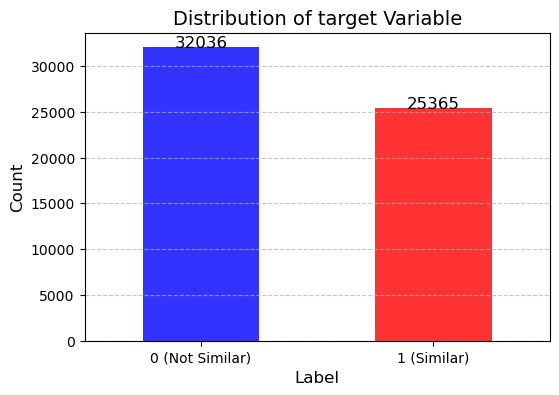

In [24]:
# Plot the distribution of the 'label' column in the train dataset
label_cnts = train['label'].value_counts()

# Create a bar plot
plt.figure(figsize=(6, 4))
bars = label_cnts.plot(kind='bar', color=['blue', 'red'], alpha=0.8)
plt.title('Distribution of target Variable', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['0 (Not Similar)', '1 (Similar)'], rotation=0, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add counts on top of the bars for readability
for i, count in enumerate(label_cnts):
    plt.text(i, count + 50, str(count), ha='center', fontsize=12)
plt.show()

## Data Preprocessing

### Convert to Lowercase

In [28]:
# Convert both sentence1 and sentence2 columns to lowercase
train['sentence1'] = train['sentence1'].str.lower()
train['sentence2'] = train['sentence2'].str.lower()
train.head()

,id,sentence1,sentence2,label
0,1,"in paris , in october 1560 , he secretly met t...","in october 1560 , he secretly met with the eng...",0
1,2,the nba season of 1975 -- 76 was the 30th seas...,the 1975 -- 76 season of the national basketba...,1
2,3,"there are also specific discussions , public p...","there are also public discussions , profile sp...",0
3,4,when comparable rates of flow can be maintaine...,the results are high when comparable flow rate...,1
4,5,it is the seat of zerendi district in akmola r...,it is the seat of the district of zerendi in a...,1


### Remove Punctuation

In [31]:
# Function to remove punctuation
def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

# Apply punctuation removal to both sentence1 and sentence2
train_1 = train.copy()  # Create a copy of the original DataFrame
train_1['sentence1'] = train_1['sentence1'].apply(remove_punctuation)
train_1['sentence2'] = train_1['sentence2'].apply(remove_punctuation)

train_1.head()


,id,sentence1,sentence2,label
0,1,in paris in october 1560 he secretly met the...,in october 1560 he secretly met with the engl...,0
1,2,the nba season of 1975 76 was the 30th season...,the 1975 76 season of the national basketball...,1
2,3,there are also specific discussions public pr...,there are also public discussions profile spe...,0
3,4,when comparable rates of flow can be maintaine...,the results are high when comparable flow rate...,1
4,5,it is the seat of zerendi district in akmola r...,it is the seat of the district of zerendi in a...,1


### Remove White space

In [34]:
# Function to remove extra whitespace
def remove_whitespace(text):
    return ' '.join(text.split())

# Apply whitespace removal to both sentence1 and sentence2
train_1['sentence1'] = train_1['sentence1'].apply(remove_whitespace)
train_1['sentence2'] = train_1['sentence2'].apply(remove_whitespace)

train_1.head()


,id,sentence1,sentence2,label
0,1,in paris in october 1560 he secretly met the e...,in october 1560 he secretly met with the engli...,0
1,2,the nba season of 1975 76 was the 30th season ...,the 1975 76 season of the national basketball ...,1
2,3,there are also specific discussions public pro...,there are also public discussions profile spec...,0
3,4,when comparable rates of flow can be maintaine...,the results are high when comparable flow rate...,1
4,5,it is the seat of zerendi district in akmola r...,it is the seat of the district of zerendi in a...,1


### Remove numbers 

In [37]:
# Function to remove numbers
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

# Apply number removal to both sentence1 and sentence2
train_1['sentence1'] = train_1['sentence1'].apply(remove_numbers)
train_1['sentence2'] = train_1['sentence2'].apply(remove_numbers)

train_1.head()


,id,sentence1,sentence2,label
0,1,in paris in october he secretly met the engli...,in october he secretly met with the english a...,0
1,2,the nba season of was the th season of the n...,the season of the national basketball associ...,1
2,3,there are also specific discussions public pro...,there are also public discussions profile spec...,0
3,4,when comparable rates of flow can be maintaine...,the results are high when comparable flow rate...,1
4,5,it is the seat of zerendi district in akmola r...,it is the seat of the district of zerendi in a...,1


### Remove Stopwords

In [40]:
# Download NLTK stopwords
nltk.download('stopwords')

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Function to remove stopwords
def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

# Apply stopword removal to both sentence1 and sentence2
train_1['sentence1'] = train_1['sentence1'].apply(remove_stopwords)
train_1['sentence2'] = train_1['sentence2'].apply(remove_stopwords)

train_1.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Magnus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,id,sentence1,sentence2,label
0,1,paris october secretly met english ambassador ...,october secretly met english ambassador nicola...,0
1,2,nba season th season national basketball assoc...,season national basketball association th seas...,1
2,3,also specific discussions public profile debat...,also public discussions profile specific discu...,0
3,4,comparable rates flow maintained results high,results high comparable flow rates maintained,1
4,5,seat zerendi district akmola region,seat district zerendi akmola region,1


### Stemming and Lemmatization

In [43]:
# Download required NLTK data
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Function for stemming
def apply_stemming(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

# Function for lemmatization
def apply_lemmatization(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

# Apply stemming to sentence1 and sentence2
train_1['sentence1_stemmed'] = train_1['sentence1'].apply(apply_stemming)
train_1['sentence2_stemmed'] = train_1['sentence2'].apply(apply_stemming)

# Apply lemmatization to sentence1 and sentence2
train_1['sentence1_lemmatized'] = train_1['sentence1'].apply(apply_lemmatization)
train_1['sentence2_lemmatized'] = train_1['sentence2'].apply(apply_lemmatization)
train_1.head()


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Magnus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Magnus\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,id,sentence1,sentence2,label,sentence1_stemmed,sentence2_stemmed,sentence1_lemmatized,sentence2_lemmatized
0,1,paris october secretly met english ambassador ...,october secretly met english ambassador nicola...,0,pari octob secretli met english ambassador nic...,octob secretli met english ambassador nicola t...,paris october secretly met english ambassador ...,october secretly met english ambassador nicola...
1,2,nba season th season national basketball assoc...,season national basketball association th seas...,1,nba season th season nation basketbal associ,season nation basketbal associ th season nba,nba season th season national basketball assoc...,season national basketball association th seas...
2,3,also specific discussions public profile debat...,also public discussions profile specific discu...,0,also specif discuss public profil debat projec...,also public discuss profil specif discuss proj...,also specific discussion public profile debate...,also public discussion profile specific discus...
3,4,comparable rates flow maintained results high,results high comparable flow rates maintained,1,compar rate flow maintain result high,result high compar flow rate maintain,comparable rate flow maintained result high,result high comparable flow rate maintained
4,5,seat zerendi district akmola region,seat district zerendi akmola region,1,seat zerendi district akmola region,seat district zerendi akmola region,seat zerendi district akmola region,seat district zerendi akmola region


In [184]:
## Since this is paws dataset and our aim is to decide if the data is paraphrased or not 
# the gramatical meaning of the word is of our interest 
# Hence we have used Lemmatisation

In [44]:
# Select only the lemmatized columns for further analysis
lemmatized_data = train_1[['sentence1_lemmatized', 'sentence2_lemmatized', 'label']]

# Rename the columns for easier reference
lemmatized_data.rename(columns={
    'sentence1_lemmatized': 'sentence1',
    'sentence2_lemmatized': 'sentence2'
}, inplace=True)

lemmatized_data.head()


,sentence1,sentence2,label
0,paris october secretly met english ambassador ...,october secretly met english ambassador nicola...,0
1,nba season th season national basketball assoc...,season national basketball association th seas...,1
2,also specific discussion public profile debate...,also public discussion profile specific discus...,0
3,comparable rate flow maintained result high,result high comparable flow rate maintained,1
4,seat zerendi district akmola region,seat district zerendi akmola region,1


### Unique Words

In [48]:
# Step 1: Getting the number of unique words in both sentences (combined)
vectorizer = CountVectorizer()
sentence_combined = lemmatized_data['sentence1'] + " " + lemmatized_data['sentence2']  # Combine both sentences
word_counts = vectorizer.fit_transform(sentence_combined)  # Get word counts

# Get unique words
unique_words = vectorizer.get_feature_names_out()
num_unique_words = len(unique_words)

# Display number of unique words
print(f"Number of unique words in combined sentences: {num_unique_words}")

Number of unique words in combined sentences: 30437


In [50]:
# Display the unique words and their counts for the first 2 rows of combined sentences
first_two_rows = sentence_combined[:2]  # Get the first two combined sentences
word_counts_first_two = vectorizer.transform(first_two_rows)  # Transform using CountVectorizer

# Get feature names (unique words)
unique_words = vectorizer.get_feature_names_out()

# Display unique words and their counts for the first 2 rows
for i, row in enumerate(word_counts_first_two):
    print(f"Row {i + 1} unique words and their counts:")
    word_count_dict = dict(zip(unique_words, row.toarray()[0]))
    for word, count in word_count_dict.items():
        if count > 0:  # Display only words with non-zero counts
            print(f"{word}: {count}")
    print("\n")

Row 1 unique words and their counts:
ambassador: 2
asked: 1
asking: 1
england: 2
english: 2
met: 2
nicolas: 2
october: 2
paris: 2
passport: 2
return: 2
scotland: 2
secretly: 2
throckmorton: 2


Row 2 unique words and their counts:
association: 2
basketball: 2
national: 2
nba: 2
season: 4
th: 2




### Frequent Words

In [53]:
# Step 2: Calculate word frequencies for the entire dataset
word_freq = np.array(word_counts.sum(axis=0)).flatten()  # Sum word counts across all rows
word_freq_dict = dict(zip(unique_words, word_freq))  # Create a dictionary of word and frequency

# Display the top 10 most frequent words across the entire dataset
print("Top 10 most frequent words in the dataset:")
sorted_word_freq = sorted(word_freq_dict.items(), key=lambda x: x[1], reverse=True)
for word, freq in sorted_word_freq[:10]:
    print(f"{word}: {freq}")


Top 10 most frequent words in the dataset:
new: 6557
first: 5885
born: 5847
also: 5621
river: 5355
state: 4034
th: 3927
district: 3768
county: 3731
school: 3592


### Compute TF 

In [193]:
# # TF = number of times a word is repeated/ Total number of words

# # Calculate Term Frequency (TF) directly on the sparse matrix
# from sklearn.preprocessing import normalize

# # Normalize word counts row-wise to get Term Frequency (TF)
# tf_sparse = normalize(word_counts, norm='l1', axis=1)  # Normalizes each row (sentence)

# # Convert to DataFrame for easier interpretation (optional, if needed in dense format)
# tf_df = pd.DataFrame.sparse.from_spmatrix(tf_sparse, columns=unique_words)

# # Add original sentences for reference
# tf_df['sentence1'] = lemmatized_data['sentence1']
# tf_df['sentence2'] = lemmatized_data['sentence2']



### Compute IDF

In [195]:
# # Step 4: Compute Inverse Document Frequency (IDF) using memory-efficient approach
# from sklearn.feature_extraction.text import TfidfTransformer

# # Initialize TfidfTransformer to compute IDF
# tfidf_transformer = TfidfTransformer(use_idf=True, smooth_idf=True)

# # Fit the transformer to calculate IDF values (on sparse word_counts)
# tfidf_transformer.fit(word_counts)

# # Extract IDF values for each word
# idf_values = tfidf_transformer.idf_
# idf_dict = dict(zip(unique_words, idf_values))  # Map each word to its IDF value

# # Display the top 10 words with the highest IDF values (most unique)
# print("Top 10 words with highest IDF values (most unique):")
# sorted_idf = sorted(idf_dict.items(), key=lambda x: x[1], reverse=True)
# for word, idf in sorted_idf[:10]:
#     print(f"{word}: {idf:.2f}")

# # Display the top 10 words with the lowest IDF values (most common)
# print("\nTop 10 words with lowest IDF values (most common):")
# sorted_idf_low = sorted(idf_dict.items(), key=lambda x: x[1])
# for word, idf in sorted_idf_low[:10]:
#     print(f"{word}: {idf:.2f}")


In [196]:
# These words appear in very few sentences, making them highly specific.

## TF-IDF Cosine Similarity

In [55]:
correlation=[]
for i in range(0,len(lemmatized_data)):
    a1=lemmatized_data["sentence1"][i]
    a2=lemmatized_data["sentence2"][i]
    tfidf = TfidfVectorizer()
    vecs = tfidf.fit_transform([a1,a2])
    corr_matrix = ((vecs * vecs.T).A)
    correlation.append(corr_matrix[0][1])

In [57]:
lemmatized_data['Similarity']=correlation
Qua=[]
for i in range(0,len(lemmatized_data)):
    if(lemmatized_data['Similarity'][i]>=0.9):
        Qua.append(1)
    else:
        Qua.append(0)

In [59]:
# # Create the 'Quality' column based on the similarity threshold
lemmatized_data['Quality'] = lemmatized_data['Similarity'].apply(lambda x: 1 if x >= 0.9 else 0)

In [61]:
lemmatized_data.head()

,sentence1,sentence2,label,Similarity,Quality
0,paris october secretly met english ambassador ...,october secretly met english ambassador nicola...,0,0.858656,0
1,nba season th season national basketball assoc...,season national basketball association th seas...,1,1.000000,1
2,also specific discussion public profile debate...,also public discussion profile specific discus...,0,0.887401,0
3,comparable rate flow maintained result high,result high comparable flow rate maintained,1,1.000000,1
4,seat zerendi district akmola region,seat district zerendi akmola region,1,1.000000,1


In [63]:
confusion_matrix = metrics.confusion_matrix(lemmatized_data["Quality"], Qua)
confusion_matrix

array([[   18, 25908],
       [    0, 31475]], dtype=int64)

In [65]:
# This confusion metric identifies the accuracy to be 54%

In [67]:
lemmatized_data["Quality"].value_counts()

Quality
1    31475
0    25926
Name: count, dtype: int64

In [205]:
# Assuming 'lemmatized_data' contains the Similarity column
low_similarity_rows = lemmatized_data[lemmatized_data['Similarity'] < 0.4]

# Display the first 5 rows with low similarity scores
low_similarity_sample = low_similarity_rows[['sentence1', 'sentence2', 'Similarity','label','Quality']].head(5)
low_similarity_sample.head()

,sentence1,sentence2,Similarity,label,Quality
6974,alaskan hawaiian,alaskan hawaiian unique label contiguous unite...,0.355477,0,0
7798,three alldublin medal ireland,three allireland medal dublin,0.336097,0,0
15553,alexandra crandell credited adam girlfriend sa...,adam w,0.230768,0,0
15561,three alldublin medal ireland,three allireland medal dublin,0.336097,0,0
19179,three alldublin medal ireland,medal dublin three allireland,0.336097,0,0


In [206]:
# Interpretation

# So according to the confusion metrics our TF IDF model gives 54% accuracy
# This method is not very good because the accuracy would alter with threshold value 

# Hence as next step we will try to extract some features from the dataset

## Feature Extraction

In [69]:
lemmatized_data.shape

(57401, 5)

In [71]:
lemmatized_data.columns

Index(['sentence1', 'sentence2', 'label', 'Similarity', 'Quality'], dtype='object')

### longest common substring (LCS)

In [74]:
#Creating a function to find the length of longest common substring (LCS)
def LCSubStr(X, Y, m, n):
    LCSuff = [[0 for k in range(n+1)] for l in range(m+1)]
    result = 0
    for i in range(m + 1):
        for j in range(n + 1):
            if (i == 0 or j == 0):
                LCSuff[i][j] = 0
            elif (X[i-1] == Y[j-1]):
                LCSuff[i][j] = LCSuff[i-1][j-1] + 1
                result = max(result, LCSuff[i][j])
            else:
                LCSuff[i][j] = 0
    return result

In [76]:
LCS=[]
for k in range(0,len(lemmatized_data)):
    lcs=LCSubStr(lemmatized_data['sentence1'][k],lemmatized_data['sentence2'][k],len(lemmatized_data['sentence1'][k]),len(lemmatized_data['sentence2'][k]))
    lcs=lcs/min(len(lemmatized_data['sentence1'][k]),len(lemmatized_data['sentence2'][k]))
    LCS.append(lcs)
lemmatized_data['LCS']=LCS

In [84]:
# Sent 1: "I Love datascience"
# Sent 2: "I love statistics and data"

# Length of longest common substring is 7 for this case


## BLEU precision and recall

In [97]:
# Sent 1: "I love statistics and data"
# Sent 2: "I Love data science"
# matcch = [I, love, data] = 3 
# total words in translation data = 4 
# precision = 3/4 = 75%  # ref
# recall = 3/5 = 60%     # ori


In [87]:
#Finding BLEU precision and recall for train data

def ngrams(string,n,i=0):   #Writing a function to find n-grams of a sentence
    while len(string[i:i+n]) == n:
        yield string[i:i+n]
        i += 1 

In [99]:
from nltk.util import ngrams
import numpy as np

# Initialize lists to store BLEU precision and recall
BLEU_precision = []
BLEU_recall = []

# Iterate over each row in lemmatized_data
for k in range(0, len(lemmatized_data)):
    # Reference text (sentence1)
    reference_text = lemmatized_data['sentence1'][k]
    uni_ref = list(ngrams(reference_text.split(), n=1))  # Generate unigrams for reference sentence
    
    # Create a list of unique unigrams from the reference
    ref_list = list(set(uni_ref))
    
    # Translation text (sentence2)
    translation_text = lemmatized_data['sentence2'][k]
    uni_trans = list(ngrams(translation_text.split(), n=1))  # Generate unigrams for translation sentence
    
    # Create a list of unique unigrams from the translation
    trans_list = list(set(uni_trans))
    
    # Count matches between reference and translation unigrams
    count = sum(1 for t in trans_list if t in ref_list)
    
    # Calculate BLEU-1 precision and recall
    bleu_p1 = count / len(trans_list) if len(trans_list) > 0 else 0
    BLEU_precision.append(bleu_p1)
    bleu_r1 = count / len(ref_list) if len(ref_list) > 0 else 0
    BLEU_recall.append(bleu_r1)

# Add BLEU-1 precision and recall to the DataFrame
lemmatized_data['BLEU1_precision'] = BLEU_precision
lemmatized_data['BLEU1_recall'] = BLEU_recall

# # Preview the updated DataFrame
# lemmatized_data[['sentence1', 'sentence2', 'BLEU1_precision', 'BLEU1_recall']].head()


In [101]:
from nltk.util import ngrams
import numpy as np

# Initialize lists for BLEU-2 precision and recall
BLEU_precision = []
BLEU_recall = []

# Iterate over each row in lemmatized_data
for k in range(len(lemmatized_data)):
    # Reference sentence (sentence1)
    reference_text = lemmatized_data['sentence1'][k]
    bi_ref = list(ngrams(reference_text.split(), n=2))  # Generate bigrams for sentence1

    # Unique bigrams in reference
    ref_list = list(set(bi_ref))

    # Translation sentence (sentence2)
    translation_text = lemmatized_data['sentence2'][k]
    bi_trans = list(ngrams(translation_text.split(), n=2))  # Generate bigrams for sentence2

    # Unique bigrams in translation
    trans_list = list(set(bi_trans))

    # Count matching bigrams
    count = sum(1 for t in trans_list if t in ref_list)

    # Calculate BLEU-2 precision and recall
    bleu_p2 = count / len(trans_list) if len(trans_list) > 0 else 0
    BLEU_precision.append(bleu_p2)
    bleu_r2 = count / len(ref_list) if len(ref_list) > 0 else 0
    BLEU_recall.append(bleu_r2)

# Add BLEU-2 precision and recall to the dataset
lemmatized_data['BLEU2_precision'] = BLEU_precision
lemmatized_data['BLEU2_recall'] = BLEU_recall

# # Display results
# lemmatized_data[['sentence1', 'sentence2', 'label','BLEU2_precision', 'BLEU2_recall']].head()

In [103]:
from nltk.util import ngrams
import numpy as np

# Initialize lists for BLEU-3 precision and recall
BLEU_precision = []
BLEU_recall = []

# Iterate over each row in lemmatized_data
for k in range(len(lemmatized_data)):
    # Reference sentence (sentence1)
    reference_text = lemmatized_data['sentence1'][k]
    tri_ref = list(ngrams(reference_text.split(), n=3))  # Generate trigrams for sentence1

    # Unique trigrams in reference
    ref_list = list(set(tri_ref))

    # Translation sentence (sentence2)
    translation_text = lemmatized_data['sentence2'][k]
    tri_trans = list(ngrams(translation_text.split(), n=3))  # Generate trigrams for sentence2

    # Unique trigrams in translation
    trans_list = list(set(tri_trans))

    # Count matching trigrams
    count = sum(1 for t in trans_list if t in ref_list)

    # Calculate BLEU-3 precision and recall
    if len(trans_list) != 0 and len(ref_list) != 0:
        bleu_p3 = count / len(trans_list)
        BLEU_precision.append(bleu_p3)
        bleu_r3 = count / len(ref_list)
        BLEU_recall.append(bleu_r3)
    else:
        BLEU_precision.append(0)
        BLEU_recall.append(0)

# Add BLEU-3 precision and recall to the DataFrame
lemmatized_data['BLEU3_precision'] = BLEU_precision
lemmatized_data['BLEU3_recall'] = BLEU_recall

# # Preview the updated DataFrame
# lemmatized_data[['sentence1', 'sentence2', 'BLEU3_precision', 'BLEU3_recall']].head()
 

In [105]:
# Initialize lists for BLEU-4 precision and recall
BLEU_precision = []
BLEU_recall = []

# Iterate over each row in lemmatized_data
for k in range(len(lemmatized_data)):
    # Reference sentence (sentence1)
    reference_text = lemmatized_data['sentence1'][k]
    quad_ref = list(ngrams(reference_text.split(), n=4))  # Generate 4-grams for sentence1

    # Unique 4-grams in reference
    ref_list = list(set(quad_ref))

    # Translation sentence (sentence2)
    translation_text = lemmatized_data['sentence2'][k]
    quad_trans = list(ngrams(translation_text.split(), n=4))  # Generate 4-grams for sentence2

    # Unique 4-grams in translation
    trans_list = list(set(quad_trans))

    # Count matching 4-grams
    count = sum(1 for t in trans_list if t in ref_list)

    # Calculate BLEU-4 precision and recall
    if len(trans_list) != 0 and len(ref_list) != 0:
        bleu_p4 = count / len(trans_list)
        BLEU_precision.append(bleu_p4)
        bleu_r4 = count / len(ref_list)
        BLEU_recall.append(bleu_r4)
    else:
        BLEU_precision.append(0)
        BLEU_recall.append(0)

# Add BLEU-4 precision and recall to the DataFrame
lemmatized_data['BLEU4_precision'] = BLEU_precision
lemmatized_data['BLEU4_recall'] = BLEU_recall

# # Preview the updated DataFrame
# lemmatized_data[['sentence1', 'sentence2', 'BLEU4_precision', 'BLEU4_recall']].head()


## Skipgram precision and recall 

In [107]:
# Sent 1: "I Love data science"
# Sent 2: "I love statistics and data"

# [ i love, love data, data science ] --> 3
# [ i love, love statistics, statistics and, and data] --> 4

# match = [ i love]

# precision= 1/4 = 25%

# recall = 1/5 = 33%

In [109]:
from nltk.util import skipgrams
import numpy as np

# Initialize lists for skipgram precision and recall
skipgram_precision = []
skipgram_recall = []

# Iterate over each row in lemmatized_data
for l in range(len(lemmatized_data)):
    # Reference sentence (sentence1)
    ref_string = lemmatized_data['sentence1'][l].split()
    trans_string = lemmatized_data['sentence2'][l].split()
  
    # Generate skipgrams for reference sentence
    skippy_ref = list(skipgrams(ref_string, 2, 4)) + list(skipgrams(ref_string, 3, 4))
        
    # Generate skipgrams for translation sentence
    skippy_trans = list(skipgrams(trans_string, 2, 4)) + list(skipgrams(trans_string, 3, 4))

    # Count matching skipgrams
    count = sum(1 for c in skippy_trans if c in skippy_ref)
    
    # Calculate skipgram precision and recall
    precision = count / len(skippy_trans) if len(skippy_trans) > 0 else 0
    recall = count / len(skippy_ref) if len(skippy_ref) > 0 else 0
    skipgram_precision.append(precision)
    skipgram_recall.append(recall)
    
# Add skipgram precision and recall to the DataFrame
lemmatized_data['Skipgram_precision'] = skipgram_precision
lemmatized_data['Skipgram_recall'] = skipgram_recall

# Display results
lemmatized_data[['sentence1', 'sentence2', 'Skipgram_precision', 'Skipgram_recall']].head()

,sentence1,sentence2,Skipgram_precision,Skipgram_recall
0,paris october secretly met english ambassador ...,october secretly met english ambassador nicola...,0.497143,0.497143
1,nba season th season national basketball assoc...,season national basketball association th seas...,0.254545,0.254545
2,also specific discussion public profile debate...,also public discussion profile specific discus...,0.573333,0.573333
3,comparable rate flow maintained result high,result high comparable flow rate maintained,0.228571,0.228571
4,seat zerendi district akmola region,seat district zerendi akmola region,0.800000,0.800000


In [110]:
lemmatized_data.head(2)

,sentence1,sentence2,label,Similarity,Quality,LCS,BLEU1_precision,BLEU1_recall,BLEU2_precision,BLEU2_recall,BLEU3_precision,BLEU3_recall,BLEU4_precision,BLEU4_recall,Skipgram_precision,Skipgram_recall
0,paris october secretly met english ambassador ...,october secretly met english ambassador nicola...,0,0.858656,0,0.580952,0.923077,0.923077,0.583333,0.583333,0.454545,0.454545,0.40,0.40,0.497143,0.497143
1,nba season th season national basketball assoc...,season national basketball association th seas...,1,1.000000,1,0.730769,1.000000,1.000000,0.666667,0.666667,0.400000,0.400000,0.25,0.25,0.254545,0.254545


## Modelling

In [113]:
### SVM 

In [115]:
#Training SVM model on 6 features
feature=lemmatized_data.drop(['sentence1','sentence2','label'],axis=1)
#features.head(5)
target=lemmatized_data['label']

x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.3, random_state=42)

0.8066895069972708

In [117]:
x_train.shape

(40180, 13)

In [119]:
x_test.shape

(17221, 13)

In [123]:
# # Prepare features and target
# features = lemmatized_data.drop(['sentence1', 'sentence2', 'label'], axis=1)
# target = lemmatized_data['label']

# # Split the data into training and testing sets
# x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Build and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=3)  # You can adjust 'n_neighbors' as needed
knn_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = knn_model.predict(x_test)

# Evaluate the model
knn_accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")


KNN Accuracy: 80.83%


In [127]:
# # Prepare features and target
# features = lemmatized_data.drop(['sentence1', 'sentence2', 'label'], axis=1)
# target = lemmatized_data['label']

# # Split the data into training and testing sets
# x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Build and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = dt_model.predict(x_test)

# Evaluate the model
dt_accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")


Decision Tree Accuracy: 80.47%


In [129]:
model=SVC()  
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
model.score(x_test,y_test)

0.8066895069972708

In [270]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Use pre-selected parameters for SVC
svc_model = SVC(C=10, kernel='rbf', gamma='scale',class_weight='balanced')  # RBF kernel with optimal parameters
svc_model.fit(x_train, y_train)

# Make predictions
y_pred = svc_model.predict(x_test)

# Evaluate the 

accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy with Tuned Parameters: {accuracy * 100:.2f}%")


SVM Accuracy with Tuned Parameters: 81.38%
